Generation 0: Best Fitness = 52441, Best Individual = 11100101
Generation 1: Best Fitness = 52441, Best Individual = 11100101
Generation 2: Best Fitness = 52441, Best Individual = 11100101
Generation 3: Best Fitness = 58081, Best Individual = 11110001
Generation 4: Best Fitness = 58081, Best Individual = 11110001
Generation 5: Best Fitness = 59536, Best Individual = 11110100
Generation 6: Best Fitness = 60025, Best Individual = 11110101
Generation 7: Best Fitness = 60025, Best Individual = 11110101
Generation 8: Best Fitness = 60025, Best Individual = 11110101
Generation 9: Best Fitness = 60025, Best Individual = 11110101
Generation 10: Best Fitness = 60025, Best Individual = 11110101
Generation 11: Best Fitness = 60025, Best Individual = 11110101
Generation 12: Best Fitness = 60025, Best Individual = 11110101
Generation 13: Best Fitness = 60025, Best Individual = 11110101
Generation 14: Best Fitness = 60025, Best Individual = 11110101
Generation 15: Best Fitness = 60025, Best Individu

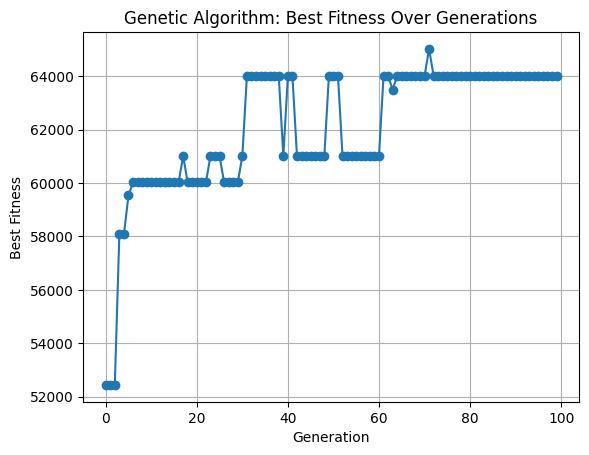

In [1]:
import random
import matplotlib.pyplot as plt

def fitness_function(x):
    return x**2
def binary_to_int(binary_str):
    return int(binary_str, 2)
def generate_population(size, chromosome_length):
    return [''.join(random.choice('01') for _ in range(chromosome_length)) for _ in range(size)]
def evaluate_population(population):
    return [fitness_function(binary_to_int(chromosome)) for chromosome in population]
def select_parents(population, fitnesses):
    total_fitness = sum(fitnesses)
    relative_fitness = [f / total_fitness for f in fitnesses]
    return random.choices(population, weights=relative_fitness, k=len(population))
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]
def mutate(chromosome, mutation_rate=0.01):
    return ''.join(bit if random.random() > mutation_rate else '1' if bit == '0' else '0' for bit in chromosome)

def genetic_algorithm(population_size, chromosome_length, generations, mutation_rate=0.01):
    population = generate_population(population_size, chromosome_length)
    best_fitness_over_time = []

    for generation in range(generations):
        fitnesses = evaluate_population(population)
        best_fitness = max(fitnesses)
        best_individual = population[fitnesses.index(best_fitness)]
        print(f"Generation {generation}: Best Fitness = {best_fitness}, Best Individual = {best_individual}")
        best_fitness_over_time.append(best_fitness)

        selected_parents = select_parents(population, fitnesses)
        next_generation = []
        for i in range(0, len(selected_parents), 2):
            parent1 = selected_parents[i]
            parent2 = selected_parents[i + 1] if i + 1 < len(selected_parents) else selected_parents[0]
            child1, child2 = crossover(parent1, parent2)
            next_generation.extend([child1, child2])

        population = [mutate(individual, mutation_rate) for individual in next_generation]  # Apply mutation to the next generation

    fitnesses = evaluate_population(population)
    best_fitness = max(fitnesses)
    best_individual = population[fitnesses.index(best_fitness)]
    print(f"Final Generation: Best Fitness = {best_fitness}, Best Individual = {best_individual}")

    plt.plot(range(generations), best_fitness_over_time, marker='o')
    plt.title('Genetic Algorithm: Best Fitness Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.grid(True)
    plt.show()

population_size = 10
chromosome_length = 8
generations = 100  # You need to define the number of generations
mutation_rate = 0.01

genetic_algorithm(population_size, chromosome_length, generations, mutation_rate)